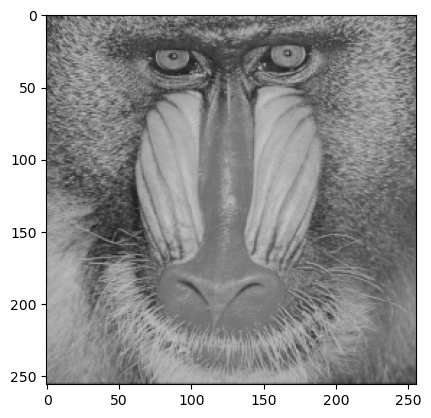

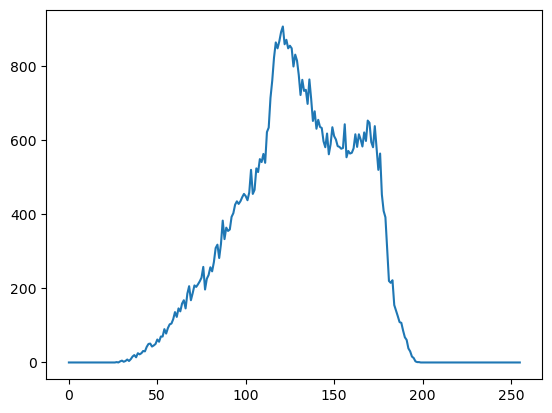

(256, 256)


In [49]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("images/baboon.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

print(image.shape)

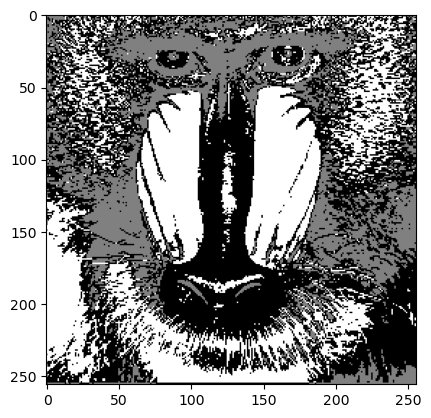

In [50]:
# Aplique el algoritmo de K-means para segmentar por agrupación. Utilice un valor de K=3. Visualice los resultados.

from sklearn.cluster import KMeans
import numpy as np

N, M = image.shape

img_flat = image.reshape(N*M, 1)

model_kmeans = KMeans(n_clusters=3)
model_kmeans.fit(img_flat)

labels = model_kmeans.labels_

segmented_image = labels.reshape(N, M)

plt.imshow(segmented_image, cmap="gray")
plt.show()


67033448.82968818
22471166.53206605
9880583.695228511
6165156.739331757
3932538.807697518
2828342.787794742
2205545.632231176
1833013.6078884308
1412142.1299430365
1173582.0666267115


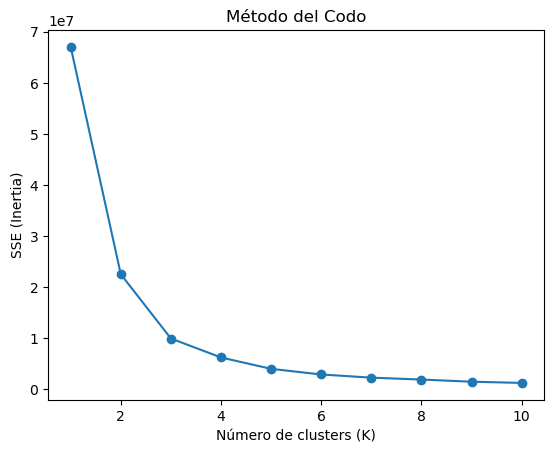

In [51]:
# Utilice el método del codo para encontrar el valor óptimo de grupos en la imagen. Visualice los resultados

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

N, M = image.shape
img_flat = image.reshape(N*M, 1)

sse = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(img_flat)
    print(kmeans.inertia_)
    sse.append(kmeans.inertia_)

plt.plot(k_values, sse, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("SSE (Inertia)")
plt.title("Método del Codo")
plt.show()

¿Cómo cambia la segmentación?
Leyendo el laboratorio, el cambio brusco en la pendiente seria K = 3, seria el numero de cluster mas optimo. Pero en el ejericio anterior habiamos establecido K = 3. Probando con K > 3, se empiezan a perder muchas regiones al categorizarlas en mas clusters 

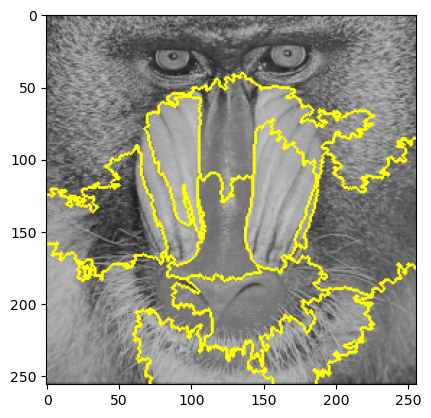

In [52]:
# Aplique el algoritmo de súperpixeles SLIC. Utilice un valor de K=25. Visualice los resultados.
from skimage.segmentation import slic
from skimage import segmentation
import matplotlib.pyplot as plt
import cv2

segments = slic(cv2.merge([image, image, image]), n_segments=25)
#Visualización de los súperpixeles superpuestos en la imagen
plt.imshow(segmentation.mark_boundaries(image, segments))


¿Cuántos súperpixeles se encontraron?
Se encontraron 12 super pixeles

Text(0.5, 1.0, 'K * 10')

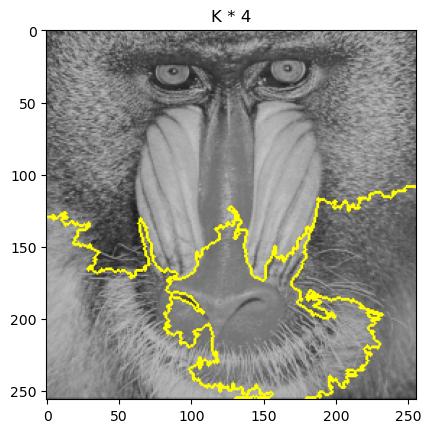

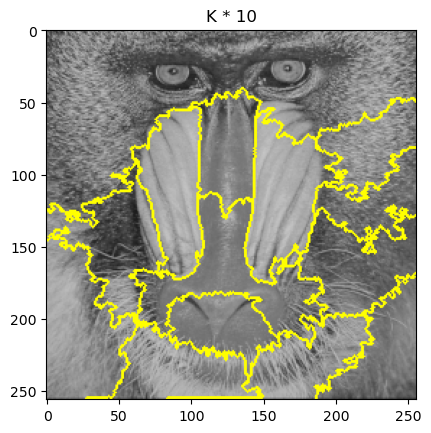

In [53]:
# Aplique el algoritmo de súperpixeles usando el valor óptimo de grupos calculado en el paso 4.
# Utilice dicho multiplicado por 4 y por 10. Visualice los resultados

# Aplique el algoritmo de súperpixeles SLIC. Utilice un valor de K=25. Visualice los resultados.
from skimage.segmentation import slic
from skimage import segmentation
import matplotlib.pyplot as plt
import cv2

K = 3 #valor optimo de clusters

segments = slic(cv2.merge([image, image, image]), n_segments=K*4)
#Visualización de los súperpixeles superpuestos en la imagen
plt.figure()
plt.imshow(segmentation.mark_boundaries(image, segments))
plt.title("K * 4")

segments2 = slic(cv2.merge([image, image, image]), n_segments=K*10)
#Visualización de los súperpixeles superpuestos en la imagen
plt.figure()
plt.imshow(segmentation.mark_boundaries(image, segments2))
plt.title("K * 10")



Qué puede observar? ¿Qué diferencias hay entre las imágenes generadas?
Se puede observar que cuando se implementa el algoritomo de SLIC con K*4 genera menos super pixeles que K*10. El algoritmo con K*10 nos genera mas super pixeles representando regiones mas pequeñas.

¿Cuál es la diferencia entre las dos técnicas de segmentación por agrupación utilizadas? ¿Cuál presenta el mejor resultado?  ¿Conclusión?